In [64]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.kernel_ridge import KernelRidge
import warnings
warnings.filterwarnings('ignore')


In [98]:
# Charger le dataset
Dataset = pd.read_csv("zara_data.csv", sep=',', decimal=',')

In [99]:
# Mettre tout le texte du dataframe en minuscules
cols_obj = Dataset.select_dtypes(include="object").columns

Dataset[cols_obj] = Dataset[cols_obj].apply(
    lambda col: col.str.lower().str.strip()
)

In [100]:
# Supprimer les lignes contenant des valeurs manquantes
Dataset= Dataset.dropna()
Dataset = Dataset.reset_index(drop=True)
print(Dataset.isnull().sum())

nom           0
url           0
couleur       0
matiere       0
prix          0
collection    0
categorie     0
dtype: int64


In [90]:
Dataset.shape

(319, 7)

In [101]:
# Convertir les colonnes "likes", "prix" et "prix_total" en numérique, en remplaçant les valeurs non convertibles par NaN
Dataset["prix"] = (
    Dataset["prix"]
    .astype(str)
    .str.replace("eur", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
)

Dataset["prix"] = pd.to_numeric(Dataset["prix"], errors="coerce")

In [70]:
Dataset['prix'].head()

0    25.99
1    39.95
2    35.95
3    35.95
4    35.95
Name: prix, dtype: float64

In [102]:
Dataset["couleur"] = Dataset["couleur"].str.replace("|", "", regex=False).str.strip()

In [103]:
Dataset['couleur'].unique()

array(['mauve poudré', 'marron', 'noir', 'unique', 'vert huile',
       'brique foncée', 'multicolore', 'léopard', 'mauve clair',
       'gris anthracite', 'brown stripes', 'beige-marron', 'écru / noir',
       'blanc', 'bleu-poudré', 'blanc\xa0/ noir', 'écru', 'bleu marine',
       'sable', 'bleu', 'bleu clair', 'beige clair', 'imprimée',
       'rouge foncé', 'blanc écru', 'bleu ciel', 'écaille', 'camel/blanc',
       'écru moyen', 'marron sable', 'bleu moyen', 'rayures', 'charbon',
       'bleu encre', 'grisâtre', 'indigo', 'vert olive', 'vert clair',
       '990', 'blanc cassé', 'marron / taupe', 'sable / chiné', 'jaune',
       'bleu roi', 'tuile', 'marron chiné', 'blanc-orange', 'argent',
       'argent mat', 'beige', 'bordeaux', 'vert kaki', 'brun',
       'gris / beige', 'bleu/noir', 'gris clair', "vert d'eau", 'rouge',
       'kaki', 'bleu / acier', 'bleu / blanc', 'vert / écru', 'turquoise',
       'bleu marine foncé', 'vert', 'fuchsia', 'rose', 'gris chiné',
       'rose flu

In [104]:
# Fonction de nettoyage pour les couleurs
def nettoyer_texte(x):
    if pd.isna(x):
        return ""
    x = str(x).lower().strip()
    x = unicodedata.normalize("NFKD", x)
    x = "".join(c for c in x if not unicodedata.combining(c))
    return x
# Appliquer la fonction de nettoyage à la colonne "couleur"
def categoriser_couleur(couleur):
    couleur = nettoyer_texte(couleur)

    if any(mot in couleur for mot in ["multicolore","rayures", "ecaille", "imprimee", "fleuri", "raye", "leopard", "zebre", "python", "/", "-"]):
        return "motif/multicolore"
    
    elif any(mot in couleur for mot in ["noir", "gris", "anthracite", "argente", "argent", "grisatre", "charbon"]):
        return "noir/gris"

    elif any(mot in couleur for mot in ["blanc", "beige", "écru", "ivoire", "creme"]):
        return "blanc/beige"

    elif any(mot in couleur for mot in ["marron", "camel", "taupe", "chocolat", "brown", "sable"]):
        return "marron"

    elif any(mot in couleur for mot in ["bleu", "marine", "turquoise", "denim", "jean", "indigo"]):
        return "bleu"

    elif any(mot in couleur for mot in ["vert", "kaki", "olive","menthe", "sauge"]):
        return "vert"

    elif any(mot in couleur for mot in ["rouge", "bordeaux", "corail", "brique", "tuile", "pourpre", "grenat"]):
        return "rouge"

    elif any(mot in couleur for mot in ["rose", "violet", "lilas", "fuchsia", "mauve", "vin"]):
        return "rose/violet"

    elif any(mot in couleur for mot in ["jaune", "orange", "ocre", "moutarde", "dore","abricot"]):
        return "jaune/orange"

    else:
        return "autre"


In [105]:
Dataset["couleur"] = Dataset["couleur"].apply(categoriser_couleur)

In [106]:
# Nettoyage de la colonne "matiere"
Dataset[["A", "B"]] = (
    Dataset["matiere"]
    .str.extract(r"(\d+)%\s*(.*)")
)

Dataset["matiere"] = (
    Dataset["B"]
    .str.split(",")
    .str[0]
    .str.strip()
)
Dataset = Dataset.drop(columns=["A", "B"])

In [107]:
Dataset['matiere'].unique()

array(['viscose', 'polyuréthane', 'lyocell', 'coton', 'bois de manguier',
       'polyester', 'lin', 'pâte de cellulose', 'cuir de vache',
       'acétate', 'cuir de chèvre', 'diacétate de cellulose', 'polyamide',
       'modal', 'papier', 'cuir de vachette', 'acier inoxydable',
       'soie (de mûrier)', 'laine', 'cuir de porc', 'pierre',
       'polyéthylène', 'verre', 'caoutchouc', 'fer', 'cuir de mouton',
       'acrylique', 'pctg', 'plastique-acrylique', 'plastique', 'cuivre',
       'élastomultiester', 'acétate de vinyle d éthylène'], dtype=object)

In [108]:
mapping = {
    # fibres naturelles végétales
    "coton": "fibre naturelle végétale",
    "lin": "fibre naturelle végétale",

    # fibres naturelles animales
    "laine": "fibre naturelle animale",
    "soie (de mûrier)": "fibre naturelle animale",

    # fibres artificielles
    "viscose": "fibre artificielle",
    "lyocell": "fibre artificielle",
    "modal": "fibre artificielle",
    "acétate": "fibre artificielle",
    "diacétate de cellulose": "fibre artificielle",
    "pâte de cellulose": "fibre artificielle",

    # fibres synthétiques
    "polyester": "fibre synthétique",
    "polyamide": "fibre synthétique",
    "acrylique": "fibre synthétique",
    "polyuréthane": "fibre synthétique",
    "polyéthylène": "fibre synthétique",
    "élastomultiester": "fibre synthétique",
    "acétate de vinyle d éthylène": "fibre synthétique",

    # cuir
    "cuir de vache": "cuir",
    "cuir de chèvre": "cuir",
    "cuir de vachette": "cuir",
    "cuir de porc": "cuir",
    "cuir de mouton": "cuir",

    # autres
    "bois de manguier": "autre",
    "papier": "autre",
    "acier inoxydable": "autre",
    "pierre": "autre",
    "verre": "autre",
    "caoutchouc": "autre",
    "fer": "autre",
    "PCTG": "autre",
    "plastique-acrylique": "autre",
    "plastique": "autre",
    "cuivre": "autre",
}
Dataset["matiere"] = (
    Dataset["matiere"]
    .str.strip()
    .str.lower()
    .map(mapping)
    .fillna("autre")
)

In [113]:
mapping_categories = {
    "hauts et t-shirts": [
        "t-shirt",
        "top",
        "haut",
        "débardeur",
        "chemise",
        "polo",
        "pull",
        "gilet"
    ],

    "pantalons et leggings": [
        "pantalon",
        "legging"
    ],

    "blazers et tailleurs": [
        "blazer"
    ],

    "costumes et tenues particulières": [
        "ensemble",
        "déguisement"
    ],

    "jupe-short": [
        "jupe-short"
    ],

    "combinaisons et combishorts": [
        "combi-short",
        "salopette"
    ],

    "jupes": [
        "jupe"
    ],

    "manteaux et vestes": [
        "veste",
        "blouson",
        "surchemise",
        "poncho",
        "ciré",
        "cape"
    ],

    "accessoires": [
        "bonnet",
        "lunettes",
        "bandana",
        "ceinture",
        "chaussettes",
        "collier",
        "chapeau",
        "porte-clés",
        "casquette",
        "portefeuille",
        "gants"
    ],

    "sweats et sweats à capuche": [
        "sweat"
    ],

    "jeans": [
        "jean"
    ],

    "chaussures": [
        "sandales",
        "mocassins",
        "espadrille",
        "sabots",
        "baskets",
        "ballerines",
        "tennis",
        "basket",
        "claquettes"
    ],

    "robes": [
        "robe"
    ],

    "autres": [
        "lot",
        "frisbee",
        "grande",
        "6-14"
    ],

    "shorts": [
        "short",
        "bermuda",
        "jort"
    ],

    "maillots de bain": [
        "maillot",
        "paréo"
    ],

    "lingerie et pyjamas": [
        
    ],

    "sacs": [
        "sac"
    ]
}

mapping_categories_inverse = {
    categorie.strip().lower(): famille
    for famille, liste_categories in mapping_categories.items()
    for categorie in liste_categories
}

In [114]:
Dataset["categorie"] = (
    Dataset["categorie"]
    .str.strip()
    .str.lower()
    .map(mapping_categories_inverse)
    .fillna("autres")
)

In [116]:
Dataset['categorie'].unique()

array(['robes', 'chaussures', 'combinaisons et combishorts', 'jeans',
       'manteaux et vestes', 'autres', 'shorts', 'hauts et t-shirts',
       'pantalons et leggings', 'jupes', 'accessoires',
       'blazers et tailleurs', 'sacs', 'sweats et sweats à capuche',
       'maillots de bain', 'costumes et tenues particulières',
       'jupe-short'], dtype=object)

In [117]:
# Enregistrer le dataset nettoyé dans un nouveau fichier CSV
Dataset.to_csv("zara_data_clean.csv", index=False)



In [110]:
Dataset[Dataset['couleur']=='autre'].shape

(31, 7)

In [112]:
Dataset["categorie"].unique()

array(['robe', 'sandales', 'combi-short', 'jean', 'veste', 'lot', 'short',
       't-shirt', 'pantalon', 'chemise', 'blouson', 'top', 'jupe',
       'bonnet', 'lunettes', 'blazer', 'sac', 'jort', 'mocassins', 'polo',
       'espadrille', 'sweat', 'bandana', 'bermuda', 'ceinture',
       'surchemise', 'chaussettes', 'débardeur', 'collier', 'sabots',
       'baskets', 'frisbee', 'chapeau', 'pull', 'maillot', 'ensemble',
       'ballerines', 'salopette', 'tennis', 'paréo', 'porte-clés',
       'basket', 'grande', 'gilet', 'jupe-short', 'casquette', '6-14',
       'haut', 'legging', 'poncho', 'ciré', 'portefeuille', 'déguisement',
       'gants', 'cape', 'claquettes'], dtype=object)

In [111]:
zara_data_clean = pd.read_csv("zara_data_clean.csv", sep=',')
zara_data_clean.head()

,nom,url,couleur,matiere,prix,collection,categorie
0,robe mi-longue fluide,https://www.zara.com/fr/fr/robe-midi-fluide-p0...,rose/violet,fibre artificielle,25.99,femme,robe
1,sandales à brides et décor métallique,https://www.zara.com/fr/fr/sandales-a-brides-e...,marron,fibre synthétique,39.95,femme,sandales
2,combi-short lyocell,https://www.zara.com/fr/fr/combinaison-courte-...,noir/gris,fibre artificielle,35.95,femme,combi-short
3,jean trf loose folded taille basse à rayures,https://www.zara.com/fr/fr/jean-trf-loose-fold...,autre,fibre naturelle végétale,35.95,femme,jean
4,robe fluide à encolure américaine,https://www.zara.com/fr/fr/robe-fluide-a-encol...,vert,fibre artificielle,35.95,femme,robe


In [82]:
# Afficher les statistiques descriptives, la forme du dataset et le nombre de valeurs manquantes
print(zara_data_clean.describe())
print(zara_data_clean.shape)
print(zara_data_clean.isnull().sum())

             prix
count  319.000000
mean    29.160909
std     21.216994
min      4.950000
25%     15.950000
50%     22.950000
75%     35.950000
max    199.000000
(319, 8)
nom           0
url           0
couleur       0
matiere       0
prix          0
collection    0
categorie     0
B             0
dtype: int64


In [83]:
zara_data_clean.describe()

,prix
count,319.000000
mean,29.160909
std,21.216994
min,4.950000
25%,15.950000
50%,22.950000
75%,35.950000
max,199.000000


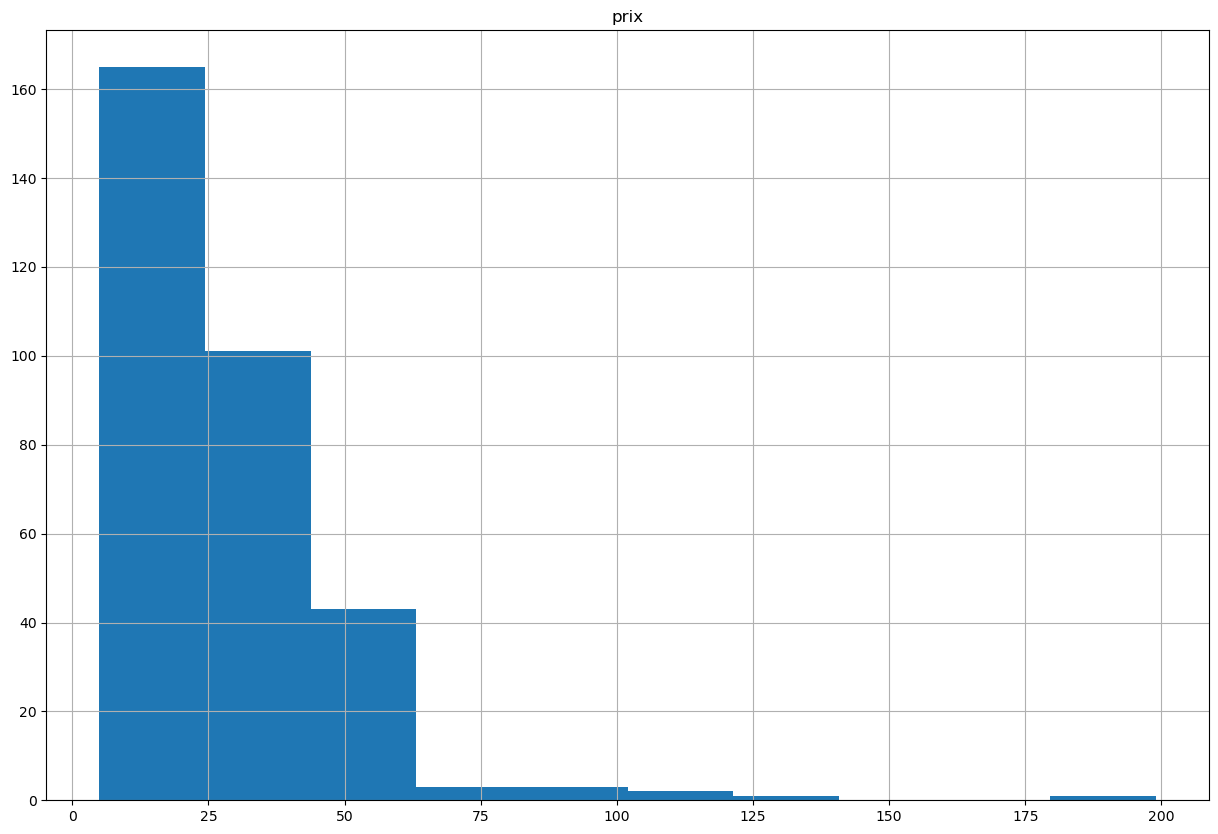

In [84]:
zara_data_clean.hist(figsize=(15,10))
plt.show()

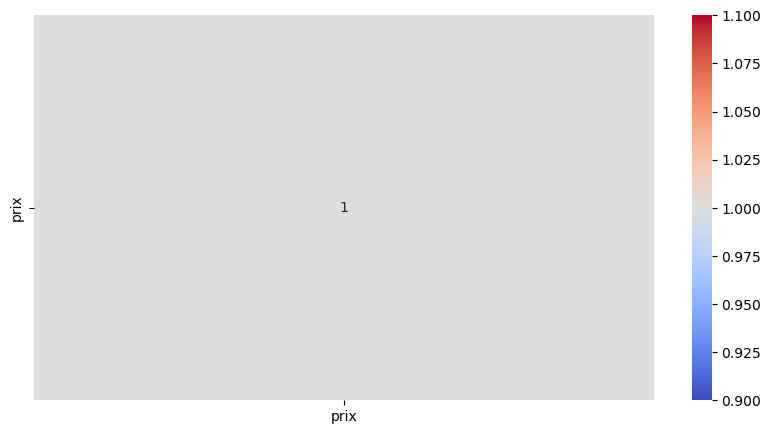

In [85]:
zara_data_clean = zara_data_clean.select_dtypes(include=[np.number])

plt.figure(figsize=(10,5))
sns.heatmap(zara_data_clean.corr(), annot=True, cmap='coolwarm')
plt.show()

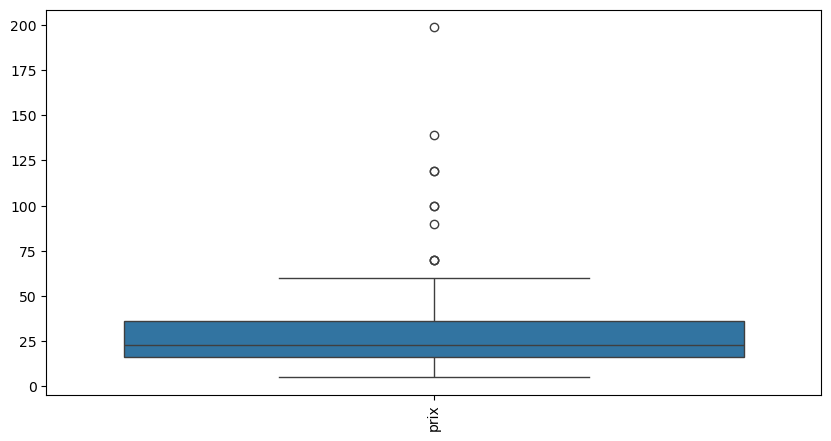

In [86]:
plt.figure(figsize=(10,5))
sns.boxplot(data=zara_data_clean.select_dtypes(include=[np.number]))
plt.xticks(rotation=90)
plt.show()